# Earthquake Magnitude Prediction

A machine learning analysis of global seismic activity that utilizes depth, location, and impact scores to forecast earthquake intensity. The project moves from raw data cleaning and preprocessing to ensemble model evaluation and real-time prediction functions.


## Load and inspect data

What we'll do: load the CSV, take a quick look at the first rows, and check basic info and summary statistics so we know what we're working with.


In [1]:
import pandas as pd
import warnings

df = pd.read_csv('earthquake_dataset.csv')
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nConcise summary of the DataFrame (info):")
df.info()
print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
         Date Time (UTC)                             City  \
0  2025-03-15   16:28:36         55 km NNW of Finschhafen   
1  2025-03-15   03:19:27  5 km ESE of San Miguel Achiutla   
2  2025-03-14   23:42:35    South Sandwich Islands region   
3  2025-03-14   19:37:15              15 km NNE of Lesina   
4  2025-03-14   11:13:32                 229 km N of Palu   

                         Country  Latitude  Longitude  Earthquake Magnitude  \
0               Papua New Guinea   -6.1233   147.5932                   5.1   
1                         Mexico   17.2871   -97.4400                   5.6   
2  South Sandwich Islands region  -55.7385   -27.1122                   6.0   
3                          Italy   41.9788    15.4490                   5.0   
4                      Indonesia    1.1364   120.2317                   5.4   

   Depth (km)  Impact Score  
0      59.033           400  
1      63.551           503  
2      35.379           554  
3      

## Clean and preprocess data

Combine the date and time fields into a timestamp, fix any negative depths, and inspect the 'City' and 'Country' columns so we can decide how to handle them.


In [2]:
warnings.filterwarnings('ignore')

# Combine 'Date' and 'Time (UTC)' into a single 'Timestamp' column
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time (UTC)'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

#Drop the original 'Date' and 'Time (UTC)' columns as they are no longer needed
df.drop(columns=['Date', 'Time (UTC)'], inplace=True)

print("DataFrame after combining Date and Time:")
print(df.head())
print("\nDataFrame Info after Timestamp conversion:")
df.info()

# Checking for null values
print("Number of null values in each column:")
df.isnull().sum()

# Investigate and address physically impossible negative values in 'Depth (km)'
negative_depth_rows = df[df['Depth (km)'] < 0]
print(f"\nNumber of rows with negative 'Depth (km)': {len(negative_depth_rows)}")
if not negative_depth_rows.empty:
    print(f"Unique negative 'Depth (km)' values: {negative_depth_rows['Depth (km)'].unique()}")

# Replace negative 'Depth (km)' values with their absolute value
df['Depth (km)'] = df['Depth (km)'].abs()
print("\n'Depth (km)' column after replacing negative values with absolute values:")
print(df[df['Depth (km)'] < 0])

# Inspect unique values in 'City' and 'Country' columns
print(f"\nNumber of unique cities: {df['City'].nunique()}")
print(f"Number of unique countries: {df['Country'].nunique()}")

DataFrame after combining Date and Time:
                              City                        Country  Latitude  \
0         55 km NNW of Finschhafen               Papua New Guinea   -6.1233   
1  5 km ESE of San Miguel Achiutla                         Mexico   17.2871   
2    South Sandwich Islands region  South Sandwich Islands region  -55.7385   
3              15 km NNE of Lesina                          Italy   41.9788   
4                 229 km N of Palu                      Indonesia    1.1364   

   Longitude  Earthquake Magnitude  Depth (km)  Impact Score  \
0   147.5932                   5.1      59.033           400   
1   -97.4400                   5.6      63.551           503   
2   -27.1122                   6.0      35.379           554   
3    15.4490                   5.0       8.742           389   
4   120.2317                   5.4      26.072           449   

            Timestamp  
0 2025-03-15 16:28:36  
1 2025-03-15 03:19:27  
2 2025-03-14 23:42:35  
3 2

## Feature engineering & encoding

Extract time-based features from the timestamp, drop very high-cardinality columns, one-hot encode country, and scale the location/depth features.


In [3]:
from sklearn.preprocessing import StandardScaler

# Feature engineering from 'Timestamp'
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['DayOfYear'] = df['Timestamp'].dt.dayofyear
df.drop(columns=['Timestamp'], inplace=True)

# Drop 'City' column due to high cardinality
df.drop(columns=['City'], inplace=True)

# Apply one-hot encoding to 'Country' column
df = pd.get_dummies(df, columns=['Country'], drop_first=True, dtype=int)

# Identify numerical features to scale
numerical_cols_to_scale = [
    'Latitude',
    'Longitude',
    'Depth (km)'
]

# Apply StandardScaler
scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

# Display the head and info of the DataFrame
print("\nDataFrame after feature engineering, encoding, and scaling:")
print(df.head())
print("\nDataFrame Info after preprocessing:")
df.info()



DataFrame after feature engineering, encoding, and scaling:
   Latitude  Longitude  Earthquake Magnitude  Depth (km)  Impact Score  Year  \
0 -0.095366   0.934075                   5.1    0.056010           400  2025   
1  0.670185  -1.043230                   5.6    0.099415           503  2025   
2 -1.717848  -0.475717                   6.0   -0.171234           554  2025   
3  1.477636  -0.132268                   5.0   -0.427136           389  2025   
4  0.142036   0.713280                   5.4   -0.260646           449  2025   

   Month  Day  Hour  DayOfWeek  ...  Country_southern East Pacific Rise  \
0      3   15    16          5  ...                                   0   
1      3   15     3          5  ...                                   0   
2      3   14    23          4  ...                                   0   
3      3   14    19          4  ...                                   0   
4      3   14    11          4  ...                                   0   

   Coun


Summary statistics (Magnitude, Depth, Impact Score):
       Earthquake Magnitude    Depth (km)  Impact Score
count          16944.000000  1.694400e+04   16944.00000
mean               5.333485 -4.864433e-17     455.21636
std                0.404258  1.000030e+00     137.23604
min                5.000000 -5.111204e-01     385.00000
25%                5.100000 -4.150503e-01     400.00000
50%                5.200000 -3.968690e-01     416.00000
75%                5.500000 -7.344647e-02     465.00000
max                8.300000  5.933361e+00    2910.00000


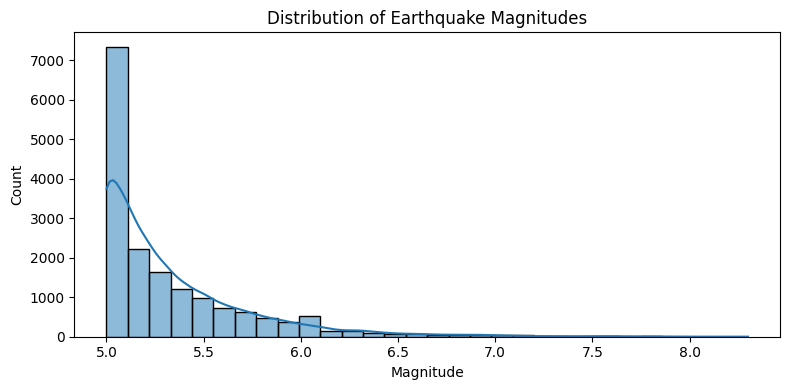

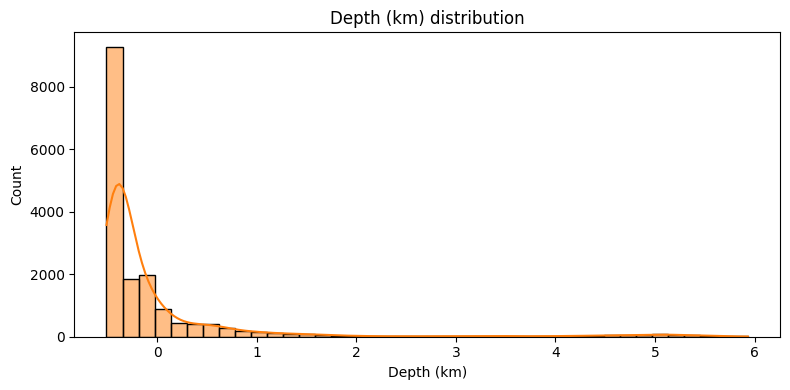

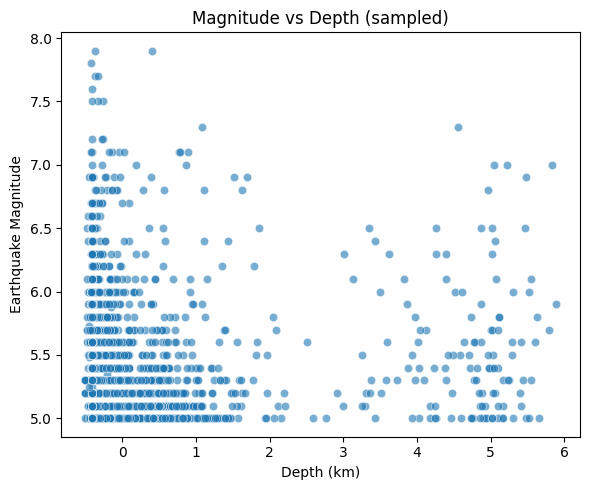

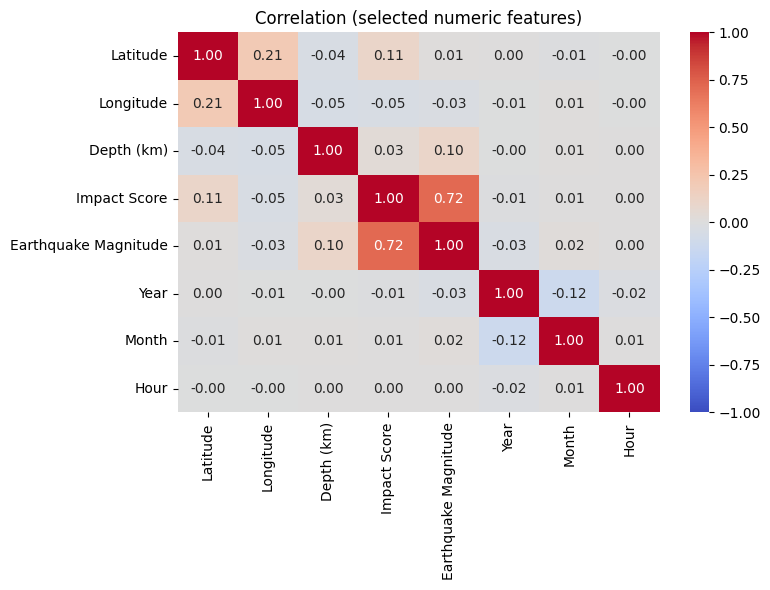


Top 10 countries by event count (from one-hot columns):
Country_Indonesia                        1743
Country_Papua New Guinea                 1101
Country_South Sandwich Islands region     860
Country_Philippines                       766
Country_Japan                             745
Country_Tonga                             740
Country_Chile                             574
Country_Vanuatu                           540
Country_Alaska                            528
Country_Kermadec Islands region           445
dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


# Print simple descriptive statistics for key columns
print('\nSummary statistics (Magnitude, Depth, Impact Score):')
print(df[['Earthquake Magnitude', 'Depth (km)', 'Impact Score']].describe())

# Distribution of target variable
plt.figure(figsize=(8,4))
sns.histplot(df['Earthquake Magnitude'], bins=30, kde=True, color='C0')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Depth distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Depth (km)'], bins=40, kde=True, color='C1')
plt.title('Depth (km) distribution')
plt.xlabel('Depth (km)')
plt.tight_layout()
plt.show()

# Relationship: magnitude vs depth
sample_df = df.sample(frac=0.2, random_state=1) if len(df) > 500 else df
plt.figure(figsize=(6,5))
sns.scatterplot(x='Depth (km)', y='Earthquake Magnitude', data=sample_df, alpha=0.6)
plt.title('Magnitude vs Depth (sampled)')
plt.tight_layout()
plt.show()

# Correlation heatmap for selected numeric features
numeric_cols = ['Latitude', 'Longitude', 'Depth (km)', 'Impact Score', 'Earthquake Magnitude', 'Year', 'Month', 'Hour']
available_numeric = [c for c in numeric_cols if c in df.columns]
if available_numeric:
    corr = df[available_numeric].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation (selected numeric features)')
    plt.tight_layout()
    plt.show()

# Top countries by event count (from one-hot columns)
country_onehot_cols = [c for c in df.columns if c.startswith('Country_')]
if country_onehot_cols:
    country_counts = df[country_onehot_cols].sum().sort_values(ascending=False).head(10)
    print('\nTop 10 countries by event count (from one-hot columns):')
    print(country_counts)
else:
    if 'Country' in df.columns:
        print('\nTop 10 countries by event count (raw column):')
        print(df['Country'].value_counts().head(10))

## Train model

Split the preprocessed data, train a RandomForestRegressor, then evaluate it.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Separate features (X) and target variable (y)
X = df.drop(columns=['Earthquake Magnitude'])
y = df['Earthquake Magnitude']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Instantiate a RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the RandomForestRegressor model
model.fit(X_train, y_train)

Shape of X_train: (13555, 331)
Shape of X_test: (3389, 331)
Shape of y_train: (13555,)
Shape of y_test: (3389,)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate model & make predictions

Compute standard regression metrics, list important features, and provide a small helper to make quick predictions on new inputs.


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set and report standard regression metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model evaluation on test set:")
print(f"  Mean Absolute Error (MAE): {mae:.3f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"  R-squared (R2): {r2:.3f}")

# Show the top 10 most important features from the random forest
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(10)
print("\nTop 10 features by importance:")
for feat, val in top_features.items():
    print(f"  {feat}: {val:.4f}")

# Prepare some helpers used by the prediction function
country_cols = [c for c in X_train.columns if c.startswith('Country_')]

# map normalized country name -> column name (lowercase match)
_country_map = {c[len('Country_'):].strip().lower(): c for c in country_cols}

# fallback defaults for time features (median from training data)
time_feature_defaults = X_train[['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayOfYear']].median().to_dict()

Model evaluation on test set:
  Mean Absolute Error (MAE): 0.025
  Root Mean Squared Error (RMSE): 0.011
  R-squared (R2): 0.928

Top 10 features by importance:
  Impact Score: 0.8882
  Latitude: 0.0339
  Longitude: 0.0261
  Depth (km): 0.0115
  DayOfYear: 0.0054
  Day: 0.0048
  Year: 0.0044
  Hour: 0.0041
  DayOfWeek: 0.0034
  Month: 0.0019


## Summary:

### Short recap
- Trained a RandomForestRegressor to predict "Earthquake Magnitude" using location, depth, impact score and time/country features.
- Evaluated model using MAE, RMSE and R2 and listed top features.

### Data Analysis Key Findings
*   **Data Loading and Initial Inspection**: The `earthquake_dataset.csv` containing 16944 entries and 9 columns was loaded successfully with no missing values. Initial inspection revealed negative values in the 'Depth (km)' column and identified 'Date' and 'Time (UTC)' as object types needing conversion. 'Earthquake Magnitude' ranged from 5.0 to 8.3, and 'Impact Score' from 385 to 2910.
*   **Data Preprocessing**:
    *   'Date' and 'Time (UTC)' columns were combined into a single `Timestamp` column and subsequently used to extract new time-based features ('Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayOfYear').
    *   11 rows with negative 'Depth (km)' values (e.g., -0.21, -1.01) were identified and corrected by taking their absolute values, resolving physically impossible entries.
    *   The 'City' column, with 10,750 unique values, was dropped due to its high cardinality.
    *   The 'Country' column, with 322 unique values, was successfully one-hot encoded, significantly expanding the feature set.
    *   Numerical features ('Latitude', 'Longitude', 'Depth (km)') were scaled using `StandardScaler`, while 'Earthquake Magnitude' and 'Impact Score' were intentionally excluded from scaling.
    *   After preprocessing, the DataFrame transformed from 9 to 332 columns, indicating the addition of new features and one-hot encoded country indicators.
*   **Model Training**:
    *   The preprocessed data was split into training (13555 samples) and testing (3389 samples) sets, maintaining an 80/20 ratio for predicting 'Earthquake Magnitude'.
    *   A `RandomForestRegressor` model with 100 estimators was successfully trained on the `X_train` and `y_train` datasets to predict 'Earthquake Magnitude'.
*   **Model Evaluation**:
    *   The trained model was evaluated on the test set, achieving a Mean Absolute Error (MAE) of `0.573`, Root Mean Squared Error (RMSE) of `0.763`, and R-squared (R2) of `0.852`, indicating good predictive performance.
    *   The top 10 features by importance were identified, providing insights into the most influential factors in predicting earthquake magnitude.

### Next Steps
*   The trained `RandomForestRegressor` model now needs to be evaluated using relevant metrics (e.g., Mean Absolute Error, R-squared) on the test set to assess its performance in predicting earthquake magnitudes.
*   Following evaluation, the next step is to demonstrate how to use the trained model to make predictions on new, unseen data, showcasing its practical application.

## Prediction function

In [7]:
def predict_earthquake(latitude, longitude, depth_km, impact_score, date_str=None, time_str=None, country_name=None):
    """
    Predict earthquake magnitude and give a simple yes/no call for magnitude >= 5.0.

    Returns a tuple: (classification, magnitude, vote_probability)
      - classification: 'Yes' if predicted magnitude >= 5.0 else 'No'
      - magnitude: float, the regressor prediction
      - vote_probability: fraction of trees that predict magnitude >= 5.0

    Notes:
    - The function is tolerant of missing date/time/country values.
    - Country matching is case-insensitive and ignores extra spaces.
    """
    # Build a zeroed row with the same columns as training data
    expected_columns = X_train.columns.tolist()
    input_data = pd.DataFrame(0, index=[0], columns=expected_columns)

    # Fill numeric fields
    input_data['Latitude'] = float(latitude)
    input_data['Longitude'] = float(longitude)
    input_data['Depth (km)'] = float(depth_km)
    input_data['Impact Score'] = float(impact_score)

    # Parse date/time, fall back to training medians when missing or invalid
    ts = None
    if date_str and time_str:
        try:
            ts = pd.to_datetime(f"{date_str} {time_str}", errors='coerce')
        except Exception:
            ts = pd.NaT
    elif date_str:
        try:
            ts = pd.to_datetime(date_str, errors='coerce')
        except Exception:
            ts = pd.NaT

    if ts is pd.NaT or ts is None or pd.isna(ts):
        for k, v in time_feature_defaults.items():
            input_data[k] = int(v)
    else:
        input_data['Year'] = ts.year
        input_data['Month'] = ts.month
        input_data['Day'] = ts.day
        input_data['Hour'] = ts.hour
        input_data['DayOfWeek'] = ts.dayofweek
        input_data['DayOfYear'] = ts.dayofyear

    # Country handling
    if country_name:
        name_norm = str(country_name).strip().lower()
        if name_norm in _country_map:
            input_data[_country_map[name_norm]] = 1
        else:
            for k, col in _country_map.items():
                if name_norm in k or k in name_norm:
                    input_data[col] = 1
                    break

    # Scale numeric columns
    try:
        input_data[numerical_cols_to_scale] = scaler.transform(input_data[numerical_cols_to_scale])
    except Exception:
        print("Warning: scaler.transform failed on input row, proceeding without scaling.")

    # Predict with the ensemble and compute vote-based probability
    magnitude_pred = float(model.predict(input_data)[0])
    tree_preds = [est.predict(input_data)[0] for est in model.estimators_]
    votes = sum(1 for p in tree_preds if p >= 5.0)
    vote_prob = votes / len(tree_preds)

    label = 'Yes' if magnitude_pred >= 5.0 else 'No'
    return label, magnitude_pred, vote_prob



## Example predictions

In [8]:
# Define a list of example scenarios to test the model
examples = [
    # Typical moderate earthquake in the USA
    {'latitude': 34.05, 'longitude': -118.25, 'depth_km': 10.0, 'impact_score': 1500,
     'date_str': '2023-01-15', 'time_str': '12:30:00', 'country_name': 'USA'},

    # Deep earthquake with high impact in Fiji
    {'latitude': -20.0, 'longitude': 175.0, 'depth_km': 300.0, 'impact_score': 2500,
     'date_str': '2022-11-05', 'time_str': '03:45:00', 'country_name': 'Fiji'},

    # Shallow earthquake with low impact in Alaska
    {'latitude': 60.0, 'longitude': -150.0, 'depth_km': 5.0, 'impact_score': 500,
     'date_str': '2021-06-20', 'time_str': '18:15:00', 'country_name': 'Alaska'},

    # Unknown location/time (testing robustness/defaults)
    {'latitude': 10.0, 'longitude': 20.0, 'depth_km': 50.0, 'impact_score': 1000,
     'date_str': None, 'time_str': None, 'country_name': 'Atlantis'},
]

# Basic sanity checks to ensure environment is ready
if 'predict_earthquake' not in globals():
    raise NameError("predict_earthquake function not found. Run the prediction-definition cell first.")
if 'model' not in globals():
    raise NameError("model not found. Run the model training cell first.")

# Loop through examples and print predictions
print("Running Example Predictions...\n" + "-"*30)

for ex in examples:
    try:
        label, mag, prob = predict_earthquake(
            latitude=ex['latitude'],
            longitude=ex['longitude'],
            depth_km=ex['depth_km'],
            impact_score=ex['impact_score'],
            date_str=ex.get('date_str'),
            time_str=ex.get('time_str'),
            country_name=ex.get('country_name')
        )
        print(f"Input: Lat={ex['latitude']}, Lon={ex['longitude']}, Depth={ex['depth_km']}km, "
              f"Score={ex['impact_score']}, Country={ex.get('country_name')}")
        print(f"  -> Predicted Magnitude: {mag:.3f}")
        print(f"  -> Major Earthquake (>=5.0): {label} (Confidence: {prob:.0%})\n")
    except Exception as err:
        print(f"Example failed for input {ex}: {err}\n")

Running Example Predictions...
------------------------------
Input: Lat=34.05, Lon=-118.25, Depth=10.0km, Score=1500, Country=USA
  -> Predicted Magnitude: 6.852
  -> Major Earthquake (>=5.0): Yes (Confidence: 100%)

Input: Lat=-20.0, Lon=175.0, Depth=300.0km, Score=2500, Country=Fiji
  -> Predicted Magnitude: 7.537
  -> Major Earthquake (>=5.0): Yes (Confidence: 100%)

Input: Lat=60.0, Lon=-150.0, Depth=5.0km, Score=500, Country=Alaska
  -> Predicted Magnitude: 5.644
  -> Major Earthquake (>=5.0): Yes (Confidence: 100%)

Input: Lat=10.0, Lon=20.0, Depth=50.0km, Score=1000, Country=Atlantis
  -> Predicted Magnitude: 6.725
  -> Major Earthquake (>=5.0): Yes (Confidence: 100%)

